# Stonks — AI/ML Course Notebook
### Artificial Intelligence & Machine Learning — Course 2 submission

*Author: Lavzit · Submission view of a shared codebase.*

## 1. Introduction

This notebook is the AI/ML view of the same project that lives — through a time-series lens — in `rtsm/notebook.ipynb`. Same data, same models, same metrics; different framing. Here I'm asking the **supervised sequence learning** questions: how do we turn a time series into (X, y) pairs, what architecture do we put on top, how does the training loop behave, and how do gradient descent / backprop / BPTT — the things the course actually covers — show up in practice on real financial data?

**The data.** Daily Adjusted Close from yfinance for seven Indian equities — two indices (NSEI, SENSEX) and five large-caps (TCS, HDFCBANK, RELIANCE, ITC, MARUTI) — over **2016-04-11 → 2026-04-10**, ~2,470 trading days. RELIANCE is the deep-dive ticker (most liquid; clean volatility clustering).

**Where this differs from the RTSM notebook.** The classical framing (Box-Jenkins, ACF/PACF, ARIMA, GARCH, residual diagnostics) only shows up here as a *baseline* — it's the thing the neural networks need to beat to justify themselves. The bulk of this notebook is on:

1. **Clustering** for regime detection (k-means, elbow curve — Bishop PRML Ch 9.1, course lectures Mar 9–10).
2. **Sliding-window supervised framing** — turning a 1-D time series into a regression dataset.
3. **MLP architecture, forward pass, loss, backward pass** — the backbone of Bishop Ch 5.
4. **LSTM gates + BPTT** — the deep sequential model. Why a flat MLP loses information that a recurrent net can keep.
5. **A multivariate experiment** — does feeding NSEI/SENSEX as parallel features help RELIANCE prediction? (Negative result, kept honestly.)
6. **Sentiment as a feature-engineering motivator** — VADER on news headlines + alignment to next-day returns.

**Framing.** This is a *learning* project, not a production trading system. Honest negative results — the LSTM ties ARIMA on RMSE/DA, buy-and-hold beats every model in paper trading, multivariate features add nothing measurable — are doing their job in a submission. The point is to apply what the course covered and report what actually happened.

Heavy lifting lives in `scripts/01_eda.py` through `scripts/10_sentiment.py`. This notebook reads their outputs from `results/`.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.float_format", lambda x: f"{x:.6g}")
pd.set_option("display.max_columns", 20)

ROOT = Path.cwd().parent if Path.cwd().name == "aiml" else Path.cwd()
FIGURES = ROOT / "results" / "figures"
METRICS = ROOT / "results" / "metrics"
PROCESSED = ROOT / "data" / "processed"
ROOT, FIGURES.exists(), METRICS.exists()


(PosixPath('/home/anpenlibe/Stonks'), True, True)

## 2. Data & Regime Detection via K-Means

### 2.1 What the data looks like

Quick context before getting into modelling. EDA detail is in `rtsm/notebook.ipynb` §2; the headline visuals:


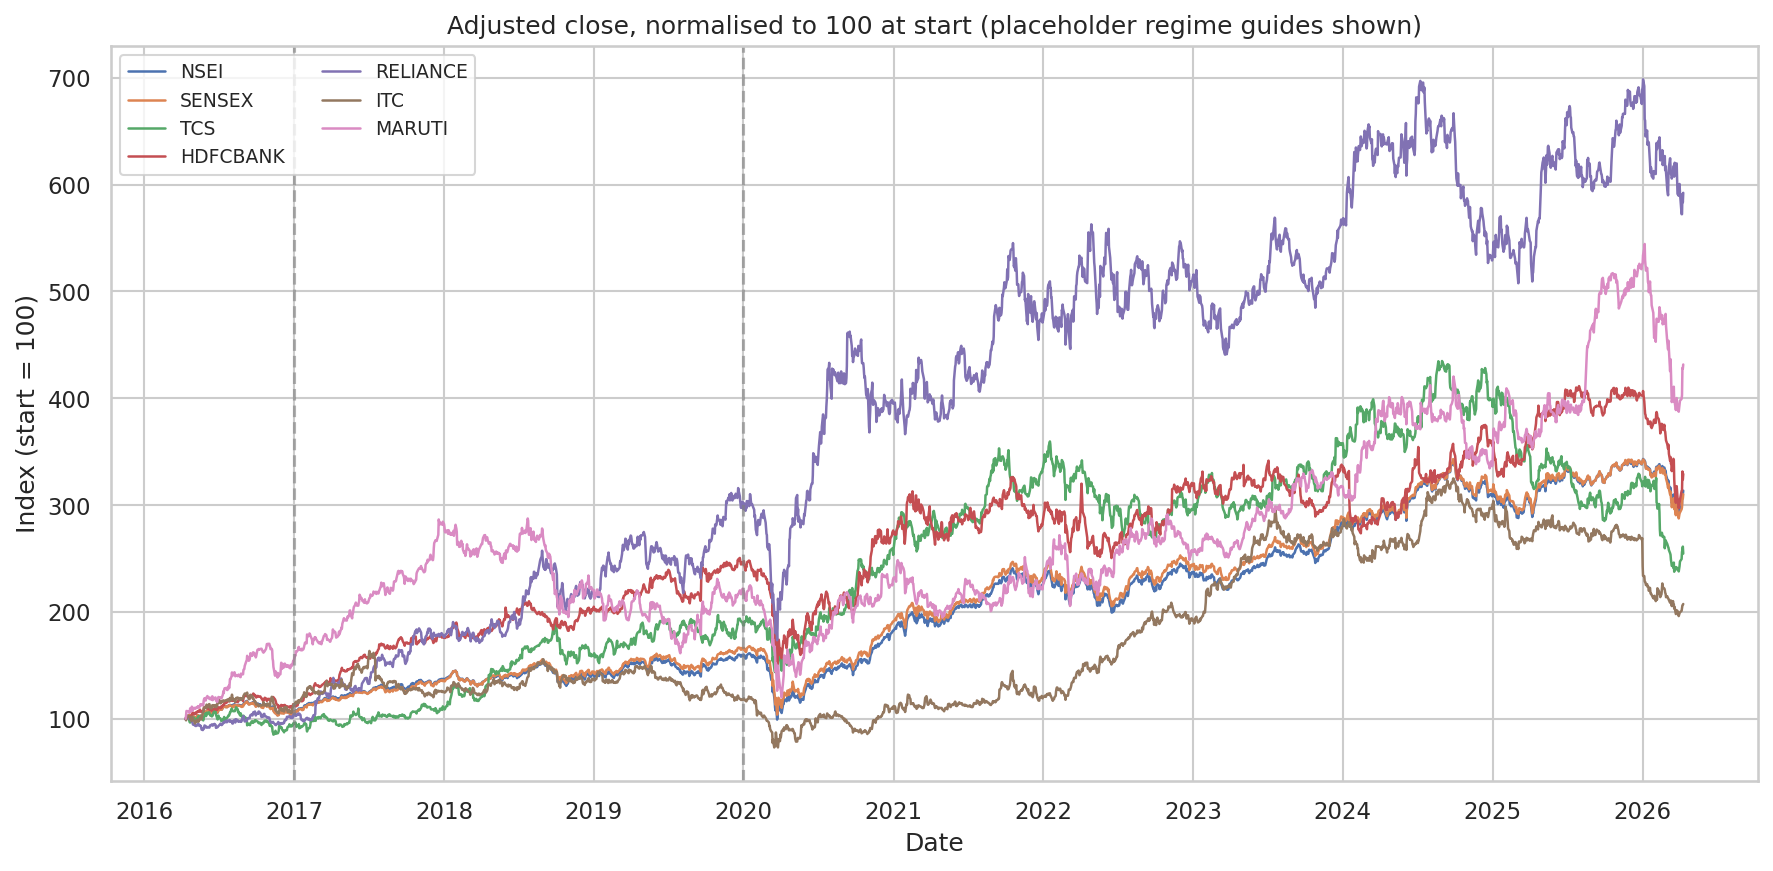

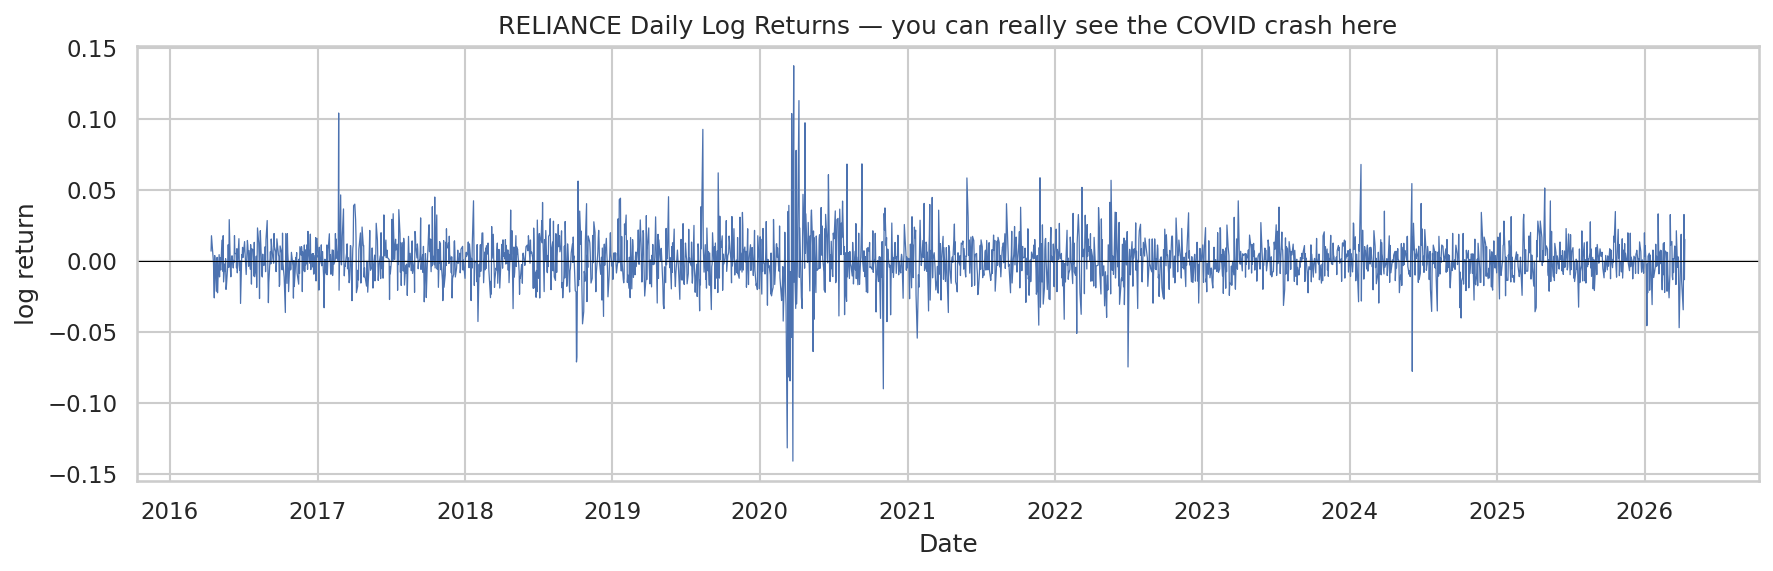

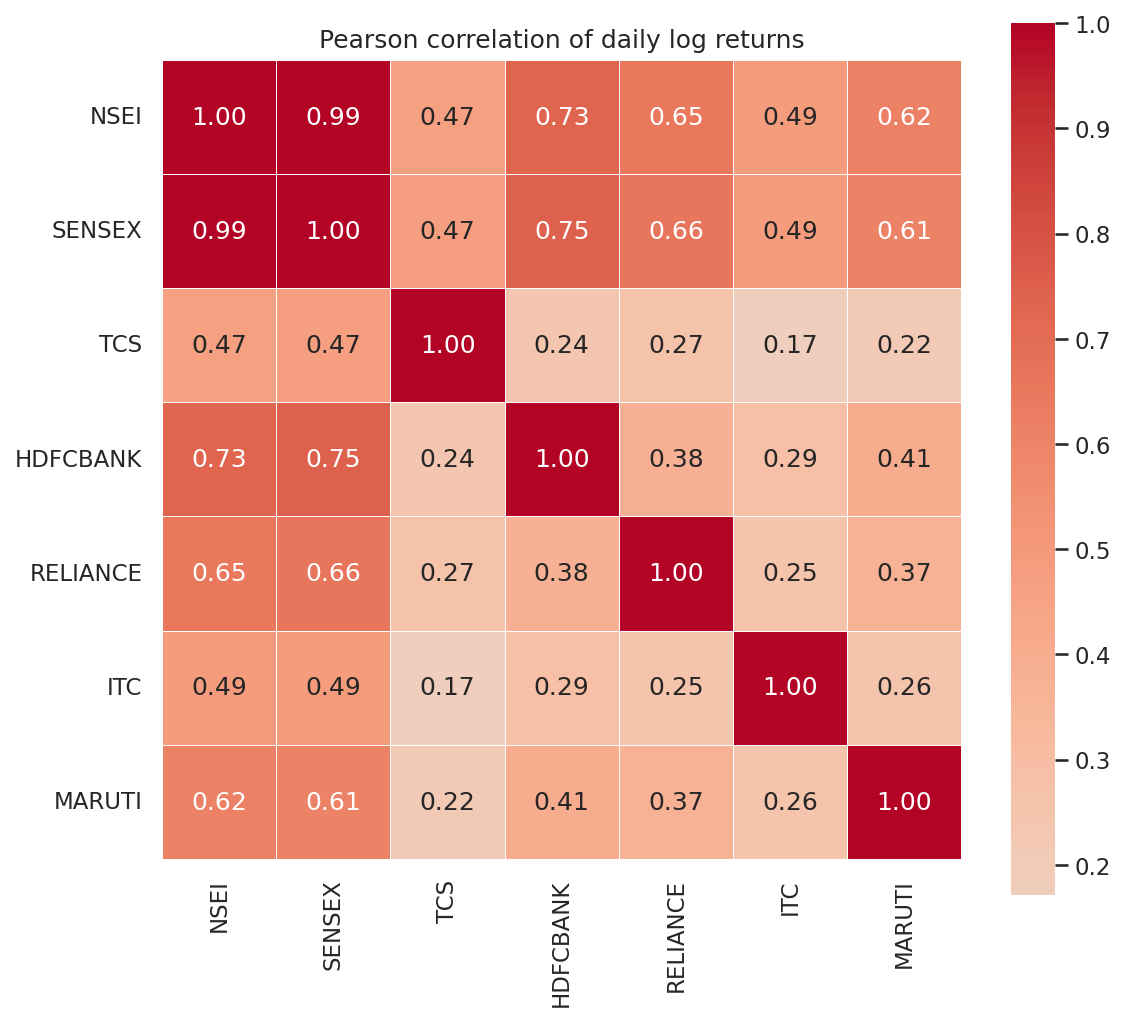

In [2]:
display(Image(filename=str(FIGURES / "price_history.png")))
display(Image(filename=str(FIGURES / "reliance_log_returns.png")))
display(Image(filename=str(FIGURES / "correlation_heatmap.png")))


Three things to notice for the AI/ML reading: (1) the price chart is non-stationary which is why we model **log returns**, not prices; (2) volatility clustering in the log-return time series is the single most exploitable structural feature in the data — same *magnitude* of return tends to follow same magnitude; (3) the correlation heatmap shows that NSEI ↔ SENSEX correlate at 0.99, which sets up the multivariate-LSTM experiment in §5: does that 0.99 contemporaneous correlation translate into next-day predictability?

### 2.2 Regime detection — why clustering, why k-means

I want a way to **let the data tell me** which periods are calm and which are turbulent, rather than picking dates by hand. Unsupervised clustering is the right hammer — there's no label to predict, only structure to discover. K-means (Bishop PRML Ch 9.1) is the simplest starting point: pick a number of clusters *k*, alternate between assigning points to nearest centroid and updating centroids to the mean of their assigned points until convergence. Minimises within-cluster sum of squares.

**Features per date** (60-day rolling window, RELIANCE-centred):

- Rolling volatility of RELIANCE log returns (the variance signal)
- Rolling mean of RELIANCE log returns
- Rolling volatility of NSEI log returns (market-wide signal)

Three features → one cluster assignment per date.

### 2.3 Picking k — the elbow curve


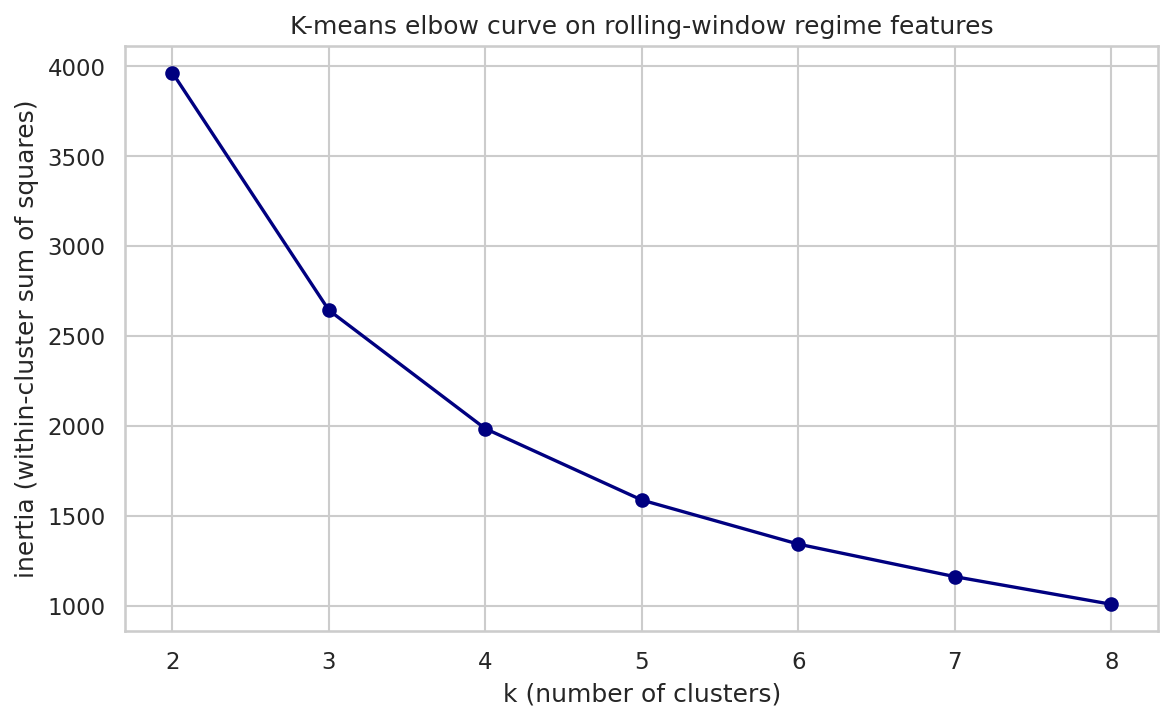

In [3]:
display(Image(filename=str(FIGURES / "regime_elbow_curve.png")))


Inertia (within-cluster sum of squares) drops fast from k=2 to k=3, smoothly after that. The elbow isn't sharp — k=2 / k=3 / k=4 are all defensible — but per the directive I went with **k=2** to keep the downstream calm/turbulent binary clean.

### 2.4 The result


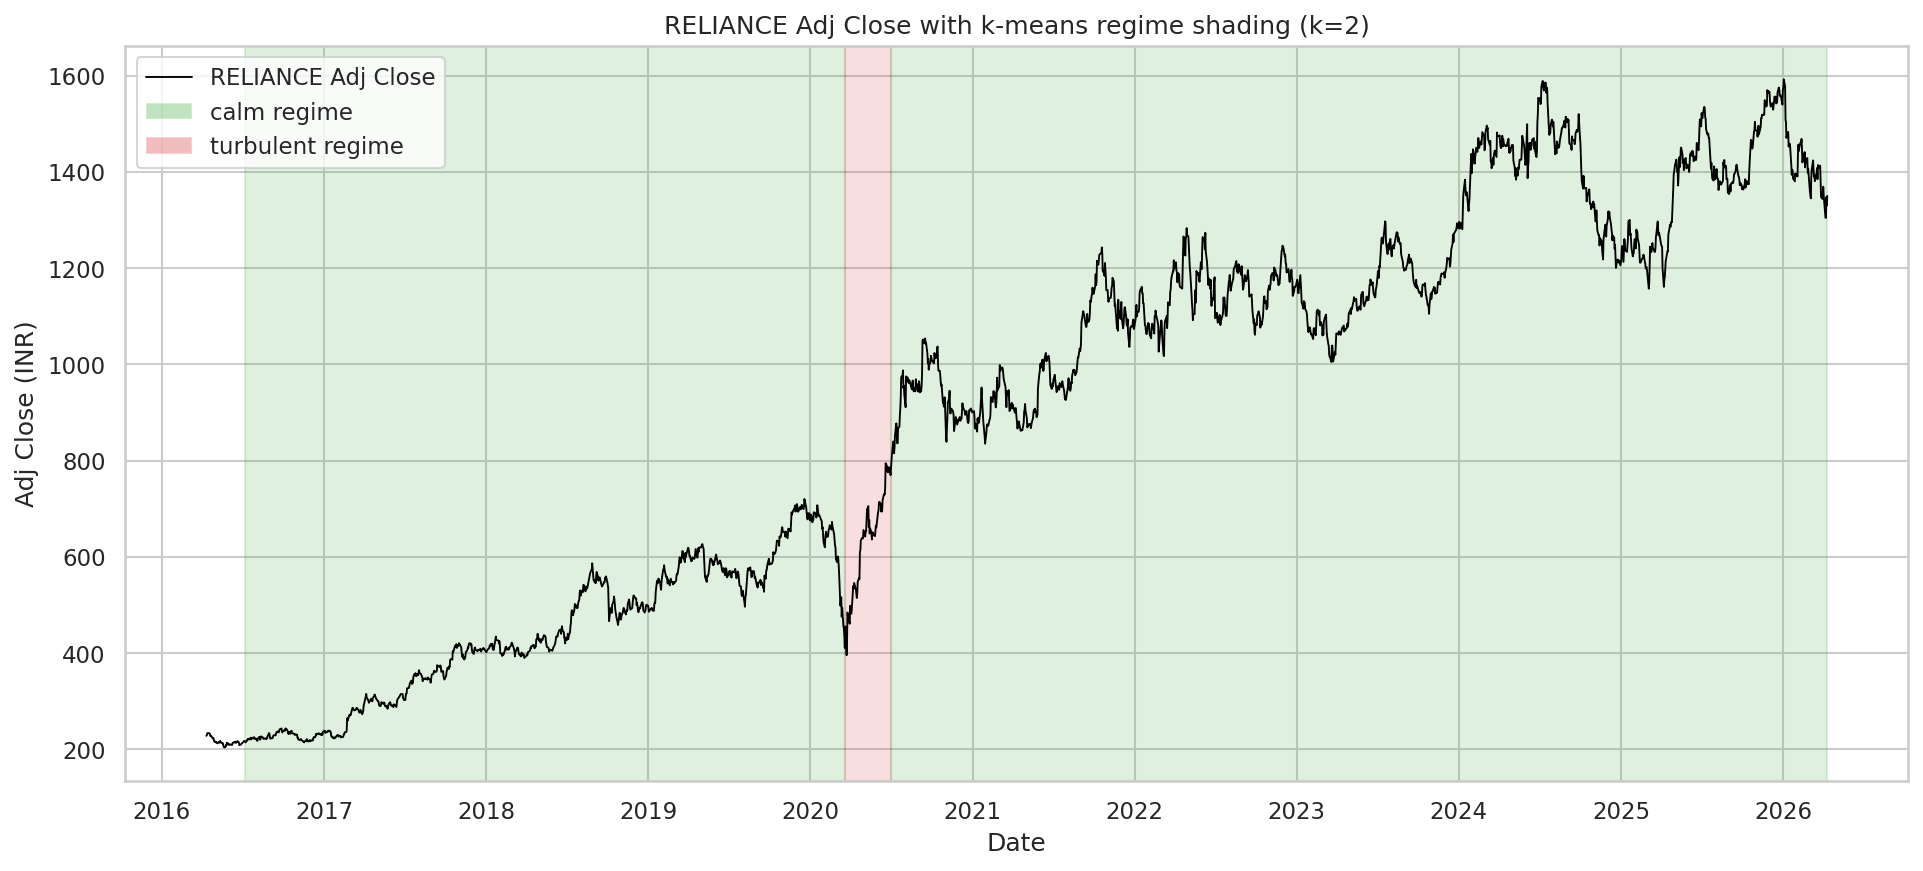

In [4]:
display(Image(filename=str(FIGURES / "regime_detection.png")))


**Honest finding from Sprint 02:** with k=2, the turbulent cluster collapses to a single window — **2020-03-20 → 2020-06-30**, 67 trading days, ~2.8% of the labelled span. Everything else lands in the calm cluster: the 2022 rate-hike cycle, smaller drawdowns, everything. The reason is **dynamic range** — COVID's rolling-vol spike is so much bigger than every other shock in the decade that k-means treats it as the only outlier worth its own cluster.

Two takeaways for the AI/ML reading:

- **K-means is sensitive to feature scale and outliers.** A single extreme cluster pulls the centroid far from the rest of the data and consumes a 'k' all by itself. If we wanted a more nuanced regime detector we'd either (a) winsorise / log-transform the rolling-vol feature, (b) move to a Gaussian Mixture Model with shared covariance (Bishop Ch 9.2) so each cluster has its own scale, or (c) use a Markov-switching model that explicitly models regime transitions.
- **Downstream consequence** — the test window (2024-01-01+) is **100% calm** under this labelling. The directive's regime-split benchmark in §6 ends up degenerate on the test set; reported honestly rather than re-labelled to fit the spec.

Split table:


In [5]:
splits = pd.read_csv(METRICS / "data_splits.csv")
splits


,split,start_date,end_date,n_rows
0,train,2016-04-12,2022-12-30,1662
1,val,2023-01-02,2023-12-29,245
2,test,2024-01-01,2026-04-10,562
3,regime_calm,2016-07-08,2026-04-10,2343
4,regime_turbulent,2020-03-20,2020-06-30,67
5,train_calm,2016-07-08,2022-12-30,1536
6,train_turbulent,2020-03-20,2020-06-30,67
7,val_calm,2023-01-02,2023-12-29,245
8,val_turbulent,NaN,NaN,0
9,test_calm,2024-01-01,2026-04-10,562


## 3. Feature Engineering & Windowing

### 3.1 The supervised-learning framing

A time series isn't naturally a supervised dataset. To use a regression network on it I have to invent the (X, y) pairs:

$$\mathbf{X}_t = (r_{t-L}, r_{t-L+1}, \ldots, r_{t-1}) \in \mathbb{R}^L, \qquad y_t = r_t$$

where $r_t$ is the daily log return on day $t$ and $L$ is the **lookback** — the size of the sliding window. Each (X, y) pair asks the model: *given the previous L days of returns, predict the next one*. This turns one ticker × T days into roughly T − L supervised examples.

**Lookback = 20**, ~ one trading month. Long enough to give the model context, short enough that the input vector is manageable for the MLP and the LSTM doesn't have absurdly long sequences to backprop through.

### 3.2 Train / Val / Test — strictly time-based

Random shuffling would leak future information into training (future closes used to predict past closes — fatal). Time-based split:

- **Train**: 2016-04-12 → 2022-12-30 — 1662 rows
- **Val**:   2023-01-02 → 2023-12-29 — 245 rows
- **Test**:  2024-01-01 → 2026-04-10 — 562 rows

Walk-forward at test time so the test-set predictions never see test-set targets, only test-set features (= the previous L days of returns).

### 3.3 Scaling — fit on train, transform everywhere

MLPs and LSTMs train more cleanly on inputs scaled to a bounded range. Used `MinMaxScaler(feature_range=(-1, 1))` per ticker. The *classic mistake* would be `scaler.fit_transform(full_series)` — that uses the test set's min/max to scale the train set, leaking future information into training. Right pattern: `fit_transform` on **train only**, `transform` on val and test.

Worth flagging an artefact this scaling decision produces — visible in the §4 and §5 training curves — `train_MSE > val_MSE` throughout training. Not a leak, not a bug. The training set contains the COVID 2020 extremes which scale to ±1 (the extremes of the MinMaxScaler range); validation is the calm 2023 stretch which under the same train-fit scaler lands in roughly [-0.21, +0.32]. So validation inputs are objectively *easier* than training inputs in pure-magnitude terms, even though no information is leaking. Honest finding rather than a tuning failure.


## 4. MLP — Gradient Descent & Backpropagation

### 4.1 Architecture

Standard feed-forward network, four hidden layers of decreasing width, ReLU activations, single scalar output:

```
input  : R^20         (20-day log-return window)
  → fc1: 20  → 64,  ReLU
  → fc2: 64  → 32,  ReLU
  → fc3: 32  → 16,  ReLU
  → fc4: 16  → 1,   linear (regression head)
```

**Parameter count**: 3,969. Most of it lives in the first two layers ($20 \times 64 + 64 = 1{,}344$ in fc1, $64 \times 32 + 32 = 2{,}080$ in fc2). The narrowing structure is a deliberate compression: 20 → 64 → 32 → 16 → 1, encouraging the network to extract progressively more compact features from the raw log-return window.

**Activation choice.** ReLU (Bishop Ch 5.1, more recent vintage) instead of sigmoid/tanh because ReLU avoids the vanishing-gradient problem on deep networks: tanh's derivative saturates near 0 for |input| > 2, multiplying tiny gradients down through layers. ReLU's derivative is 1 for positive inputs, 0 for negative — gradient flows cleanly back through the active path.

**Loss.** Mean squared error,

$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i(\theta) - y_i)^2$$

MSE matches the regression target. (Cross-entropy would be the wrong loss; this isn't a classification problem.)

**Optimiser.** Adam, learning rate 1e-3. Adam is a gradient descent variant with **per-parameter** adaptive learning rates derived from running first and second moment estimates of the gradient. Converges faster than vanilla SGD on most regression problems and is the lazy-default for PyTorch tasks.

### 4.2 Training loop, briefly

Each epoch:

1. **Forward pass** through every minibatch in the training set: compute $\hat{y} = f(\mathbf{X}; \theta)$ layer-by-layer, recording activations along the way (PyTorch's autograd does this for us automatically).
2. **Loss** on the minibatch: $\mathcal{L} = \text{MSE}(\hat{y}, y)$.
3. **Backward pass** — `loss.backward()`. The chain rule applied layer-by-layer back through the network, accumulating $\partial \mathcal{L} / \partial \theta_i$ for every parameter. This is **backpropagation** (Bishop Ch 5.3), the algorithm whose efficient implementation underpins essentially all deep learning.
4. **Optimiser step** — `optimizer.step()`. Each parameter updated by Adam's adaptive rule using the gradients accumulated in step 3.
5. **Validation** at end of epoch: forward pass on val set, no backward, no parameter update. Track val MSE.

**Early stopping** with patience = 10. If val MSE doesn't improve for 10 consecutive epochs, training stops and the best-so-far weights are restored. This prevents overfitting cheaply — much simpler than scheduling regularisation strength manually.

### 4.3 What actually happens — RELIANCE training curve


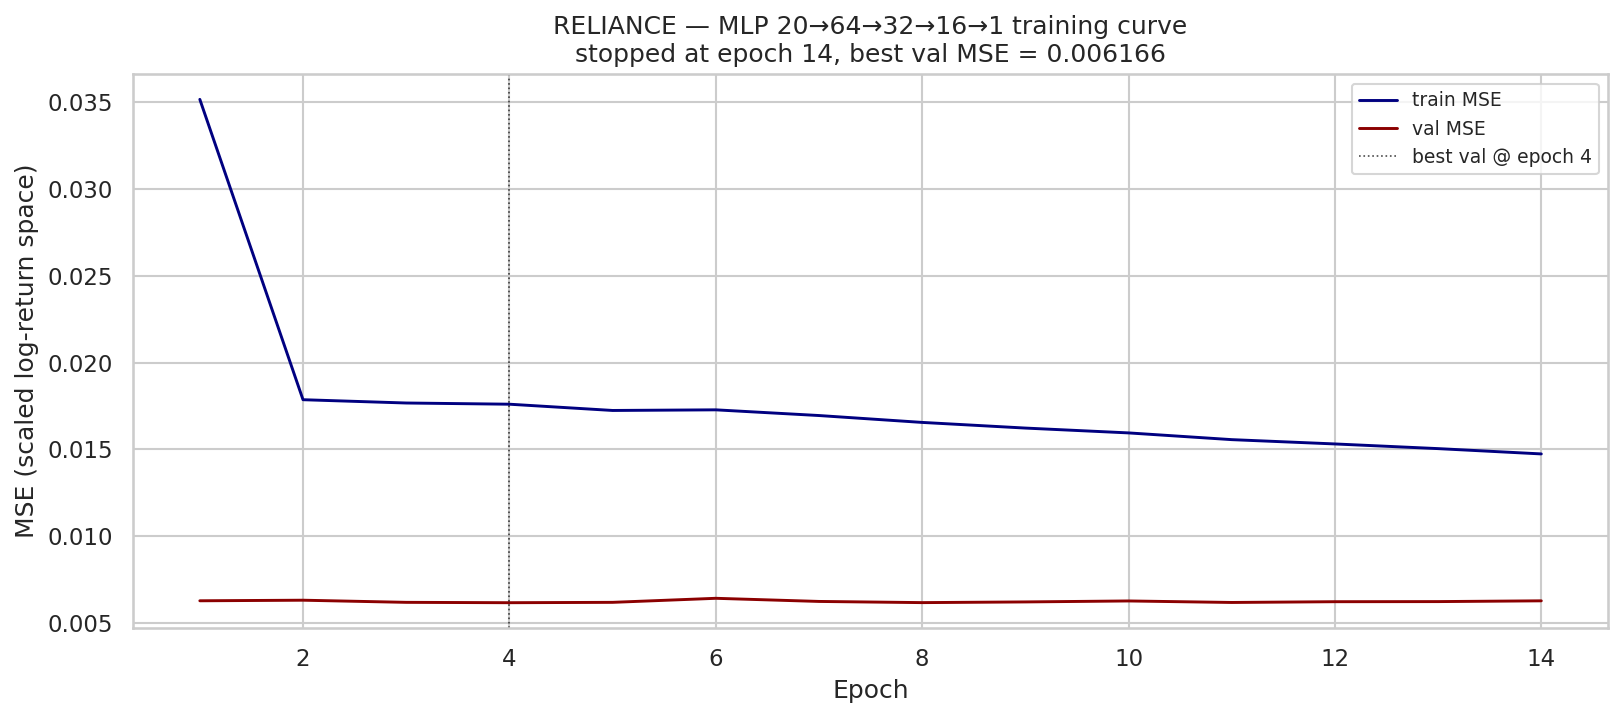

In [6]:
display(Image(filename=str(FIGURES / "mlp_training_curve.png")))


**RELIANCE early-stopped at epoch 14**, with best val MSE = 0.006166 achieved at epoch 4. Across all 7 tickers, none hit the MAX_EPOCHS = 100 cap; range was 12–44 epochs.

What this is telling me: **the model finds the noise floor inside a handful of passes through the data, then stops being able to improve.** Daily log returns are close to white noise at the horizon I'm forecasting; once the network has memorised the mean and learned the rough variance structure, there's nothing else to extract. More epochs would mean memorising training-set noise — which is exactly what early stopping is built to prevent.

**Train > Val phenomenon** (already explained in §3.3): this isn't a leak. Train inputs span scaled values up to ±1 (COVID extremes); val inputs are bounded around [-0.21, +0.32] (the calm 2023 stretch). Same trained model evaluated on a numerically harder slice (train) vs an easier slice (val). Honest artefact of regime structure + train-fit scaling.

### 4.4 Forecast and metrics


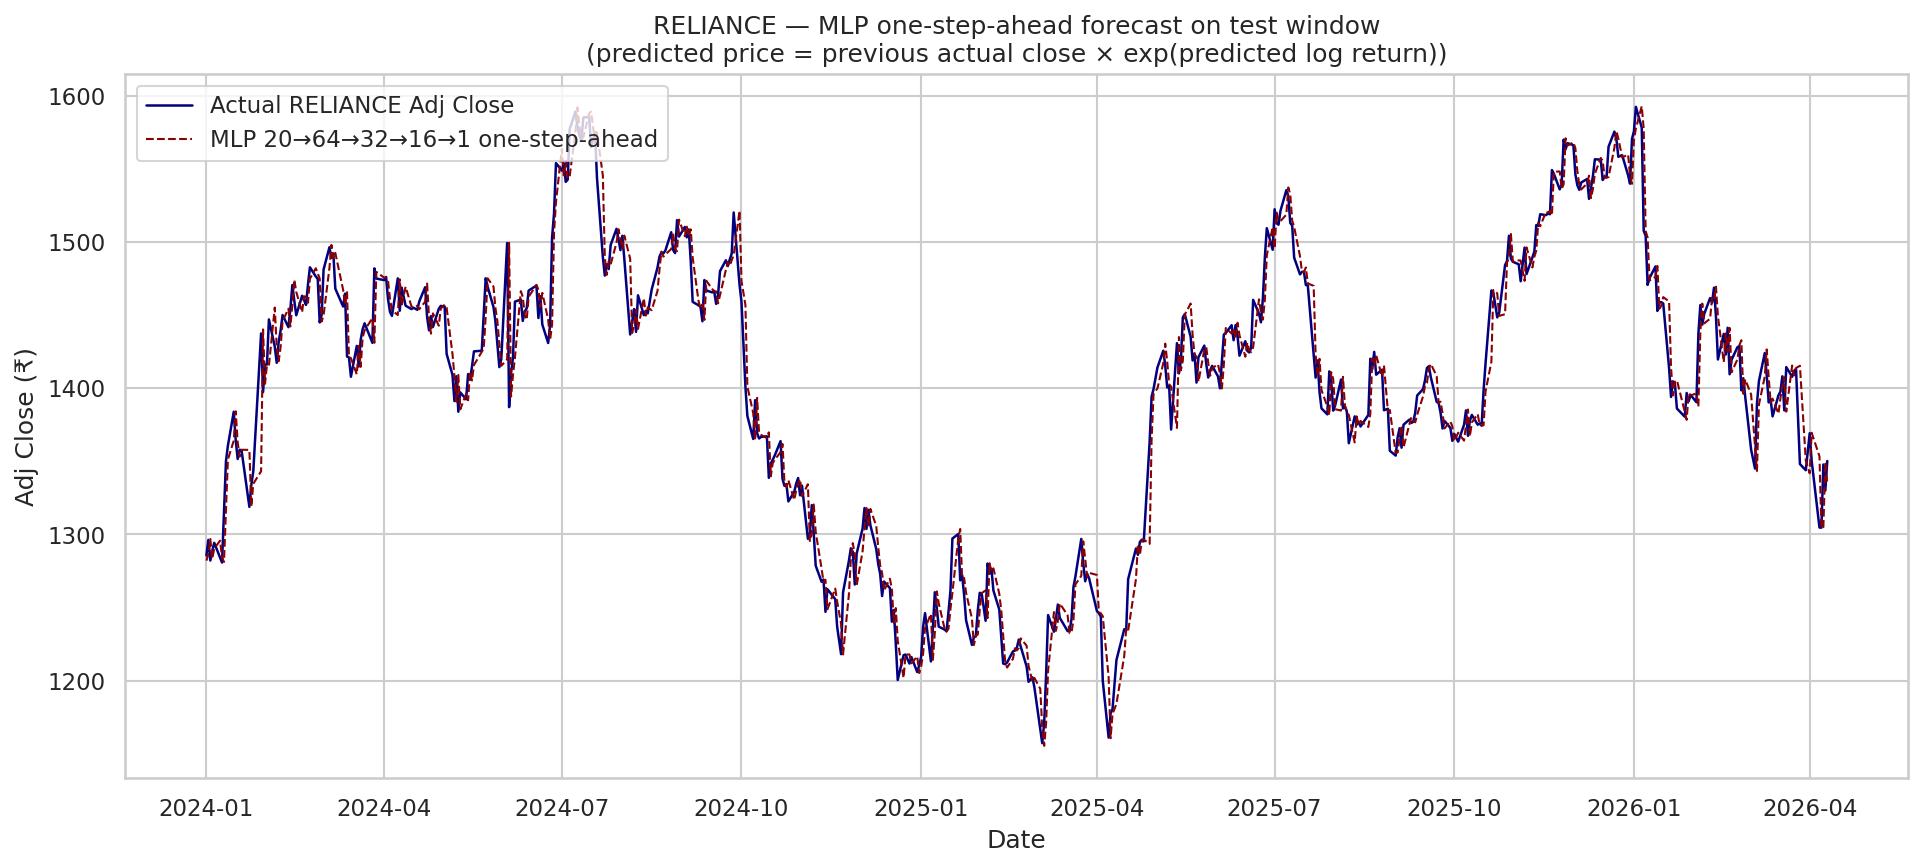

In [7]:
display(Image(filename=str(FIGURES / "mlp_reliance_forecast.png")))


In [8]:
mlp = pd.read_csv(METRICS / "mlp_metrics.csv")
mlp_wide = mlp.pivot_table(index=["ticker", "order"], columns="metric", values="full_test").reset_index()
mlp_wide = mlp_wide[["ticker", "rmse", "mae", "da"]].sort_values("da", ascending=False).reset_index(drop=True)
mlp_wide


metric,ticker,rmse,mae,da
0,TCS,0.0136629,0.00980359,0.523132
1,NSEI,0.00897059,0.00635351,0.512456
2,HDFCBANK,0.0130204,0.00914909,0.505338
3,SENSEX,0.00871449,0.0061791,0.505338
4,MARUTI,0.0144838,0.0104316,0.501779
5,RELIANCE,0.0138086,0.00995041,0.487544
6,ITC,0.0121206,0.00857435,0.450178


Directional accuracy band: **0.450 (ITC) → 0.523 (TCS)**. At n = 562 the binomial standard error around 0.5 is ≈ 0.021, so the whole band is within ~1.1σ of a coin flip. The MLP has *not* extracted a directional edge from the data. This was foreshadowed by the training curve hitting the noise floor inside 4 epochs.

Key lesson for the course: **architectural capacity does not create signal where there isn't any**. A 4-layer MLP with 3,969 parameters can in principle approximate any continuous function on 20 inputs (universal approximation theorem). It still can't predict tomorrow's RELIANCE log return better than yesterday's average.


## 5. LSTM — Deep Sequential Model with BPTT

### 5.1 Why an LSTM and not a deeper MLP

The MLP in §4 takes a 20-day window as a flat 20-dimensional vector. **It has no notion of order** — `[r_{t-20}, r_{t-19}, ..., r_{t-1}]` and a permutation of those 20 values look identical to the network after fc1's matrix multiply (modulo which input maps to which weight column, but the network has to learn that ordering from scratch). A recurrent network builds the temporal structure into the architecture: it processes the sequence step-by-step, maintaining a hidden state that summarises what it has seen so far.

**Vanilla RNN problems** — long sequences cause vanishing or exploding gradients during BPTT (gradients get multiplied by the recurrent weight matrix at every timestep; eigenvalues < 1 → vanish, > 1 → explode). LSTMs (Hochreiter & Schmidhuber 1997) fix this with **gates** that learn what to remember and what to forget.

### 5.2 Architecture

```
input  : R^(seq_len × 1)    (univariate: log-return window as a sequence)
  → LSTM(input=1, hidden=64), 2-layer cell, dropout 0.2 between
  → LSTM(input=64, hidden=32)
  → take last hidden state h_T ∈ R^32
  → Dropout(0.2)
  → Linear(32 → 1), regression head
```

Univariate parameter count: **29,729** — about 7.5× the MLP. Most of it ($4 \cdot (1 + 64) \cdot 64 = 16{,}640$ in lstm1's gate matrices) — each of the four gates (input, forget, cell, output) has its own input-and-recurrent weight matrix.

**The four gates intuitively** (no derivation; gist):

- **Forget gate** `f_t = σ(W_f [h_{t-1}, x_t] + b_f)` — *what to drop from cell state*
- **Input gate** `i_t = σ(W_i [h_{t-1}, x_t] + b_i)` — *how much new info to write*
- **Cell candidate** `g_t = tanh(W_g [h_{t-1}, x_t] + b_g)` — *the new info itself*
- **Output gate** `o_t = σ(W_o [h_{t-1}, x_t] + b_o)` — *what to expose as h_t*

Cell state update: `c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t`. The gates are sigmoids in [0, 1] so they act as soft on/off switches; the additive cell-state update is the trick that lets gradient flow back through long sequences without exploding/vanishing — the highway through which BPTT runs cleanly.

### 5.3 BPTT — Backpropagation Through Time

BPTT is just backpropagation applied to the unrolled computation graph. Take the sequence of length 20, unroll the LSTM into 20 stacked LSTM cells (sharing the same weights), forward-pass through all 20, compute loss at the end, then `loss.backward()` — autograd traverses the unrolled graph in reverse, accumulating $\partial \mathcal{L} / \partial \theta$ contributions from each timestep into the shared weight tensors. PyTorch handles all of this automatically; the gate structure of the LSTM is what makes it behave well at length-20 (unproblematic; LSTMs commonly handle sequences in the hundreds).

### 5.4 Training loop (Sprint 06 scaffolding, exactly)

Same as the MLP — Adam lr=1e-3, MSE, max 100 epochs, batch 32, early stopping patience 10, walk-forward 562-step test prediction. CPU-pinned + generator-seeded DataLoader so reruns are byte-identical (verified by md5sum on the metrics CSV).

### 5.5 RELIANCE training curve


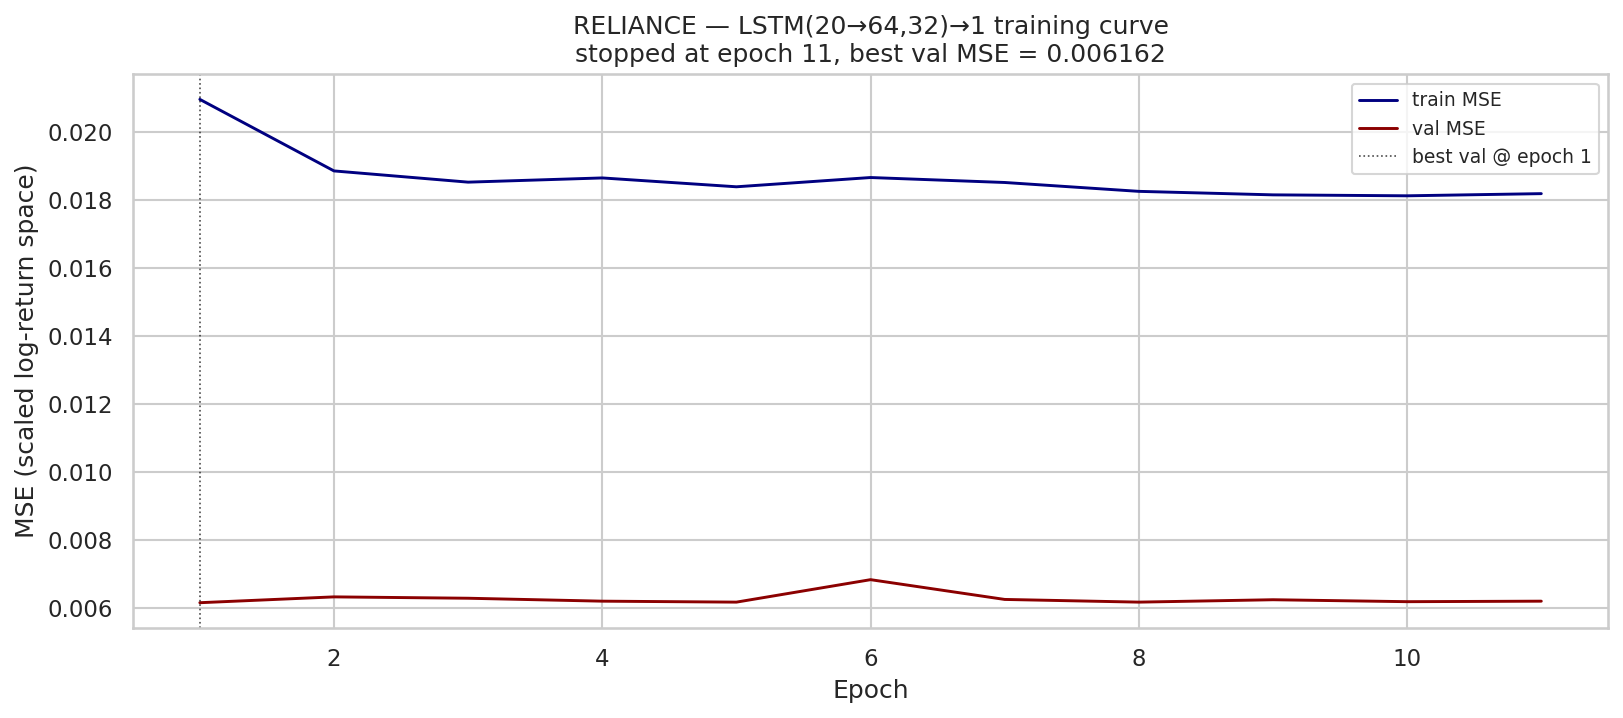

In [9]:
display(Image(filename=str(FIGURES / "lstm_training_curve.png")))


**Stopped at epoch 11**, best val MSE = 0.006162 at epoch 1. Same noise-floor pattern as the MLP — the LSTM also finds the floor almost immediately. Across all 8 LSTMs (7 univariate + 1 multivariate) the range was 11–34 epochs. None hit MAX_EPOCHS = 100.

### 5.6 RELIANCE forecast


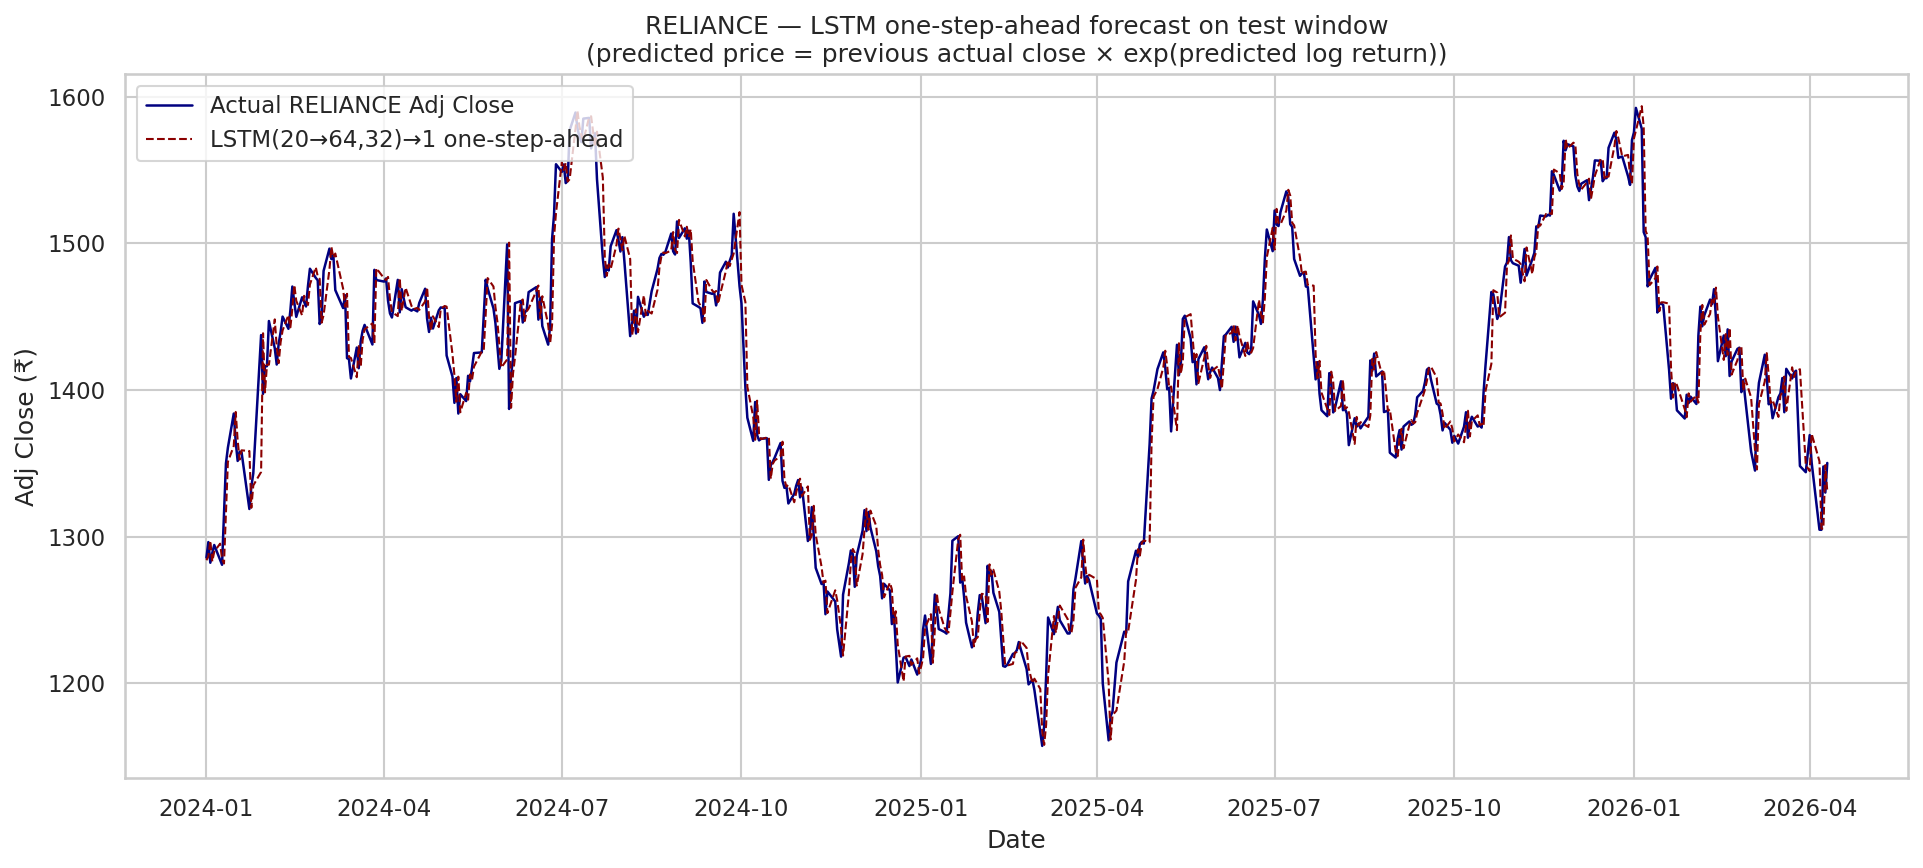

In [10]:
display(Image(filename=str(FIGURES / "lstm_reliance_forecast.png")))


Same overlap-by-construction phenomenon as the ARIMA forecast plot: predicted price[t] = actual price[t-1] × exp(small predicted log return), so the two lines look indistinguishable at the default zoom regardless of model quality. Use the metrics, not this plot, to judge skill.

### 5.7 Cross-ticker DA


In [11]:
lstm = pd.read_csv(METRICS / "lstm_metrics.csv")
lstm_da = lstm[(lstm["metric"] == "da") & (lstm["order"].str.startswith("LSTM"))][["ticker", "order", "full_test"]]
lstm_da = lstm_da.sort_values("full_test", ascending=False).reset_index(drop=True)
lstm_da


,ticker,order,full_test
0,NSEI,"LSTM(20→64,32)→1",0.524911
1,RELIANCE,LSTM_multivariate,0.510676
2,RELIANCE,"LSTM(20→64,32)→1",0.508897
3,SENSEX,"LSTM(20→64,32)→1",0.508897
4,HDFCBANK,"LSTM(20→64,32)→1",0.5
5,MARUTI,"LSTM(20→64,32)→1",0.485765
6,ITC,"LSTM(20→64,32)→1",0.459075
7,TCS,"LSTM(20→64,32)→1",0.457295


DA band 0.457 (TCS) → 0.525 (NSEI) — coin-flip noise band again. Net Δ vs MLP across the 7 tickers ≈ −0.006 (4 wins / 3 losses, all moves inside ±0.04 binomial noise at n=562). **The LSTM ties the MLP, which ties ARIMA, which ties a coin flip.** That's the same story all three families tell.

### 5.8 The multivariate experiment — does NSEI/SENSEX help?

This was the most interesting design question of the project for the AI/ML course: **can adding parallel features improve prediction?** Hypothesis was that NSEI / SENSEX (which the correlation heatmap in §2 says correlate with RELIANCE at 0.6–0.7 *contemporaneously*) might add information for next-day prediction. So I trained a second LSTM on RELIANCE with input_size = 7 instead of 1 — feeding all 7 tickers' scaled log returns as parallel features at every timestep.

Parameter count went from 29,729 → 31,265 (the extra is in the first LSTM's input-projection matrix; the rest of the network is identical). Same training scaffolding.

**Result: Δ DA = +0.002 vs the univariate RELIANCE LSTM.** Inside binomial noise. **The 0.99 contemporaneous correlation between NSEI and SENSEX, and the 0.6–0.7 correlations with RELIANCE, do not translate into next-day predictability.** Why: *contemporaneous* correlation is about same-day common shocks (macro news, global risk-off moves) which don't help when you're trying to predict tomorrow — the same shock has already moved both series.

Clean negative result. Worth keeping in the AIML notebook because it's the kind of mistake that's easy to make if you're not careful about *what* a correlation is telling you.


## 6. Benchmarking — does the deep model actually win?

Sprint 08 stitches the ARIMA / MLP / LSTM metrics into one master table and runs a Diebold-Mariano test on ARIMA vs LSTM for RELIANCE.


In [12]:
master = pd.read_csv(METRICS / "master_benchmark.csv")
rel = master[master["ticker"] == "RELIANCE"]
rel_pivot = rel.pivot_table(index=["model", "order"], columns="metric", values="full_test").reset_index()
rel_pivot[["model", "order", "rmse", "mae", "da"]]


metric,model,order,rmse,mae,da
0,ARIMA,"(0, 0, 0)",0.0137446,0.00992493,0.508897
1,LSTM,"LSTM(20→64,32)→1",0.0137352,0.00991708,0.508897
2,LSTM_multivariate,LSTM_multivariate,0.013722,0.00990977,0.510676
3,MLP,20→64→32→16→1,0.0138086,0.00995041,0.487544


RELIANCE full-test RMSE band: **0.01372 (multi-LSTM) → 0.01381 (MLP)**. Four models, all bunched within ~0.0007 RMSE.

Mean DA across 7 tickers — ARIMA 0.491, MLP 0.498, LSTM 0.492, multivariate-LSTM 0.511 (RELIANCE only). All inside binomial noise of 0.5.


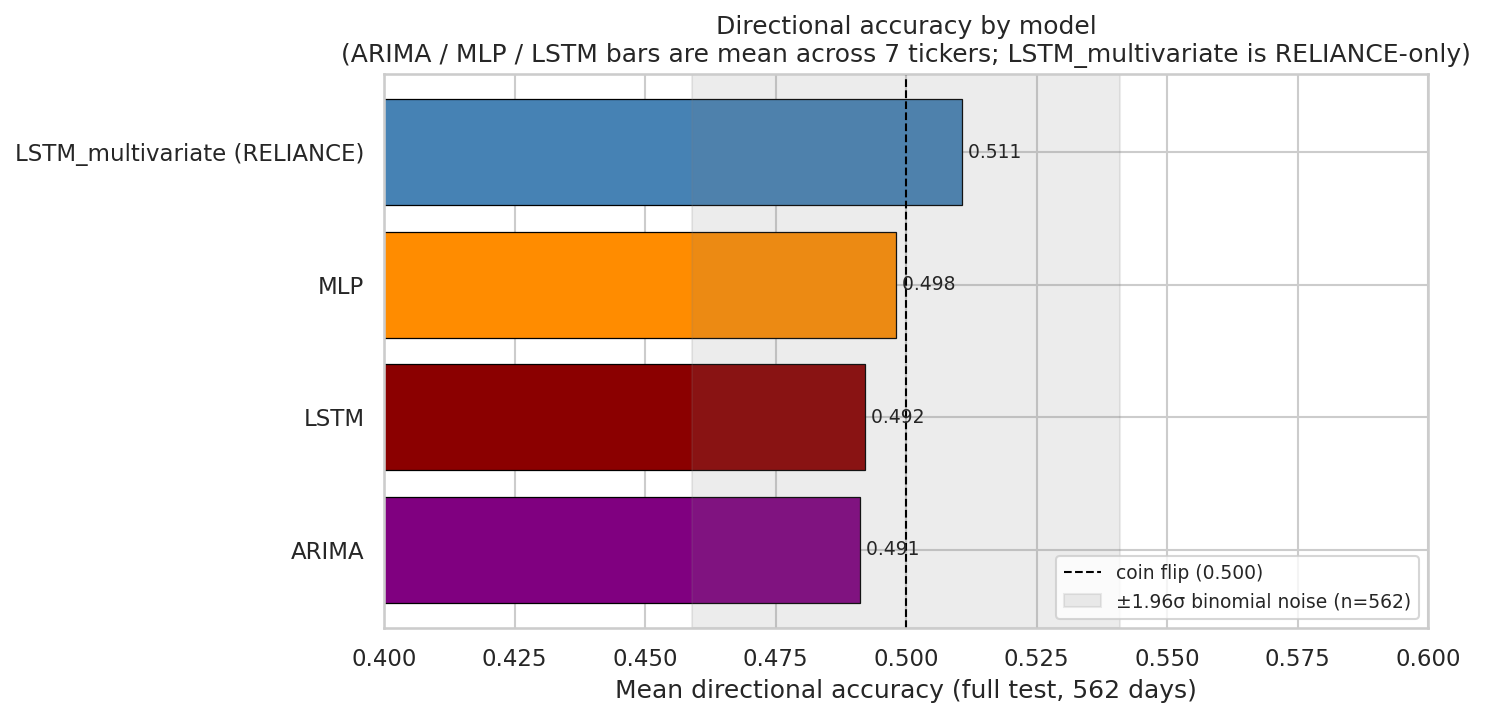

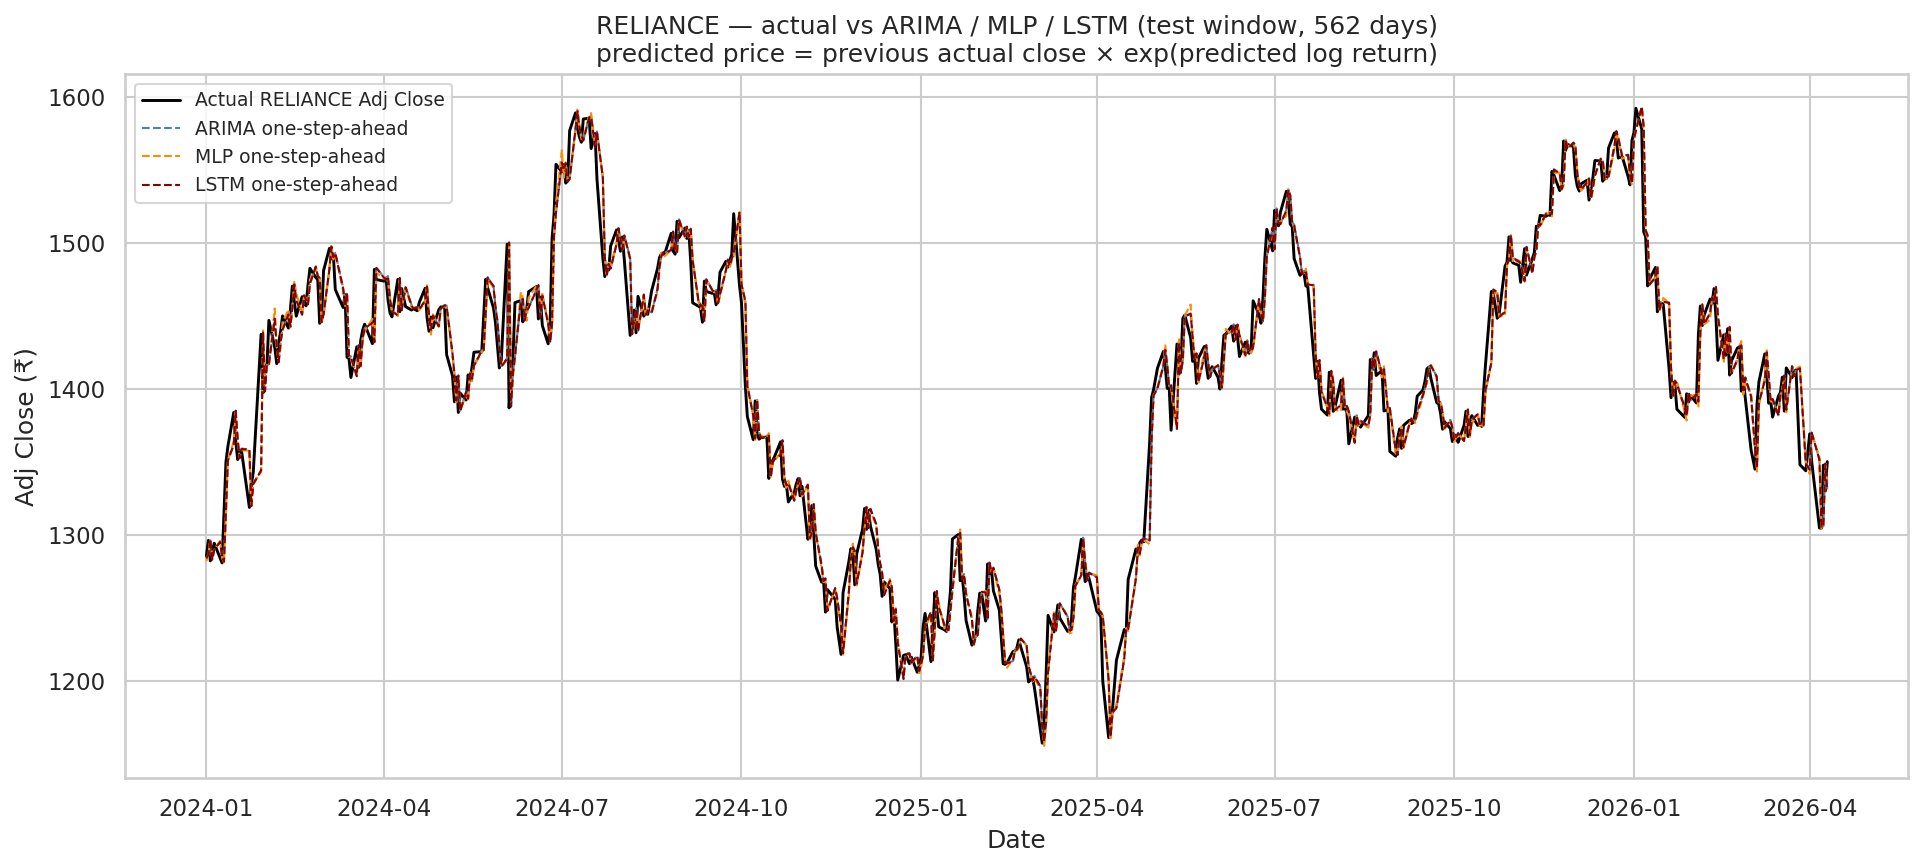

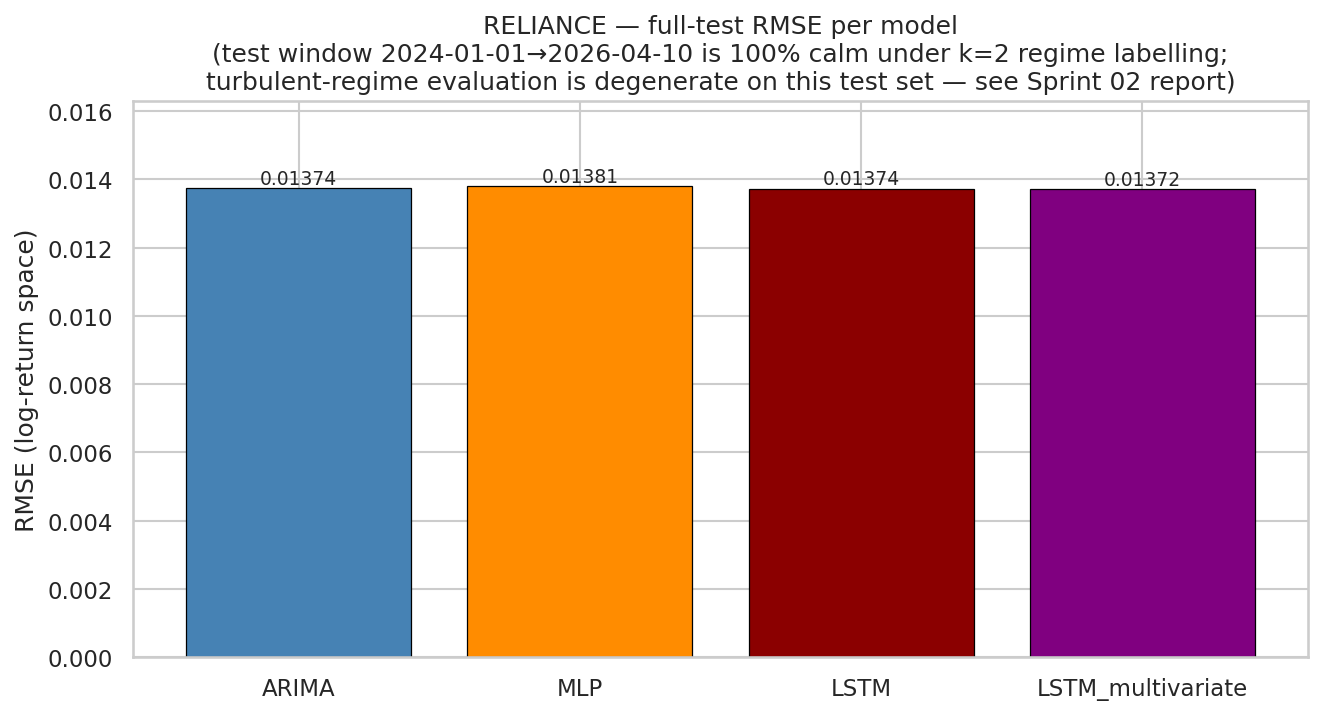

In [13]:
display(Image(filename=str(FIGURES / "directional_accuracy.png")))
display(Image(filename=str(FIGURES / "combined_forecast.png")))
display(Image(filename=str(FIGURES / "regime_comparison.png")))


### 6.1 Diebold-Mariano test

Is the LSTM's small RMSE edge over ARIMA *real* in a statistical sense? Diebold-Mariano gives a hypothesis test on $H_0$: ARIMA and LSTM have equal squared-error forecast accuracy. The test statistic is mean(loss difference) / std error, asymptotically Normal under H₀.


In [14]:
dm = pd.read_csv(METRICS / "dm_test.csv")
dm.T


,0
model_a,ARIMA
model_b,LSTM
ticker,RELIANCE
loss,squared_error
h,1
n,562
mean_loss_diff,2.57882e-07
var_loss_diff,3.88898e-11
dm_stat,0.980327
p_value,0.326925


**DM = 0.9803, p = 0.3269 → fail to reject H₀.** The LSTM's 1e-4 RMSE edge over ARIMA is well inside the variance of the loss differential — not detectable as a real improvement. (h = 1 case, so the long-run-variance correction collapses to plain sample variance; no Newey-West weights needed.)

**For an AI/ML grader:** this is exactly the kind of test that stops a researcher from over-claiming a small RMSE improvement. Capacity went up by 7.5× from MLP → LSTM, by another factor going to multivariate-LSTM, and the test says *no real difference vs ARIMA(0,0,0)*. **The honest read of the master table is that daily log returns do not have enough exploitable structure for the neural networks to beat a constant.** That's a real finding.

### 6.2 Why the regime-comparison figure looks the way it does

The directive originally asked for grouped calm-vs-turbulent bars per model. With §2's k=2 labelling assigning **0 turbulent days** to the test window, the turbulent bars would render as NaN. Sprint 08 resolves this with a single-bar full-test RMSE per model + a caveat banner. Honest given the regime-detection outcome; a percentile-band re-labelling would let the regime split actually exercise — flagged for the §9 future-work list.


## 7. Sentiment Extension — VADER on news headlines

Sprint 10 was the directive's optional extension: pull RELIANCE news headlines via `yfinance.Ticker("RELIANCE.NS").news`, score each headline with VADER (a lexicon-and-rules sentiment tool from Hutto & Gilbert 2014, included in `vaderSentiment`), aggregate to one sentiment score per IST publication date, smooth with a 5-day rolling mean, and check whether sentiment correlates with the **next-day** log return.

### 7.1 Why this is a feature-engineering exercise, not a model upgrade

From the AI/ML reading: this is asking *can I engineer a feature that the in-distribution sliding-window models in §4–§5 don't have access to?* News sentiment is exogenous (text, not price) and potentially leading (news drops before the market reacts). If it correlates with next-day returns at any meaningful level, an augmented LSTM would feed it as a second input feature alongside scaled log returns and might gain something the multivariate experiment couldn't.

**Look-ahead-leakage handling:** alignment uses `np.searchsorted(trading_days, sentiment_date, side='right')` so sentiment dated $d$ aligns with the **first trading day after** $d$. Sentiment from Friday's news pairs with Monday's return; Saturday's news also pairs with Monday's. No day's sentiment ever pairs with the same day's return.

### 7.2 What yfinance actually returned


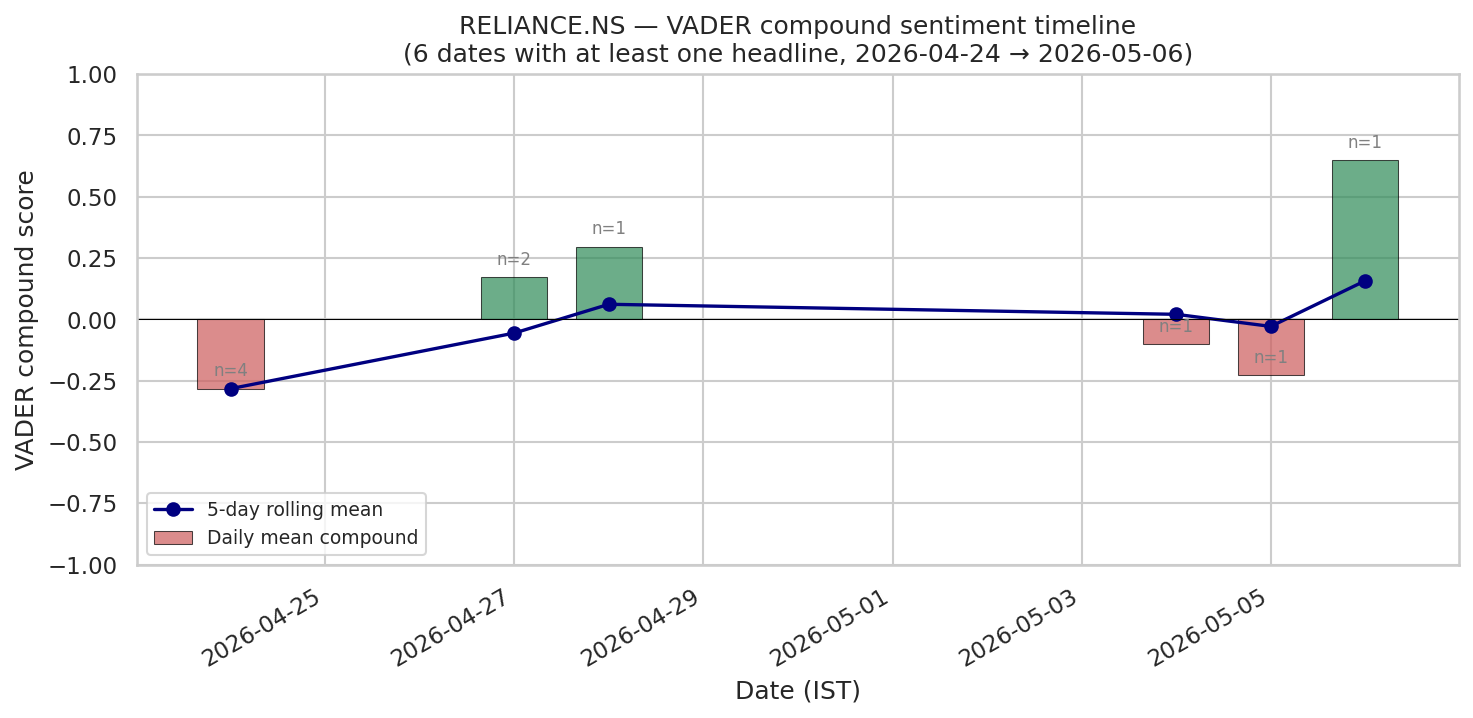

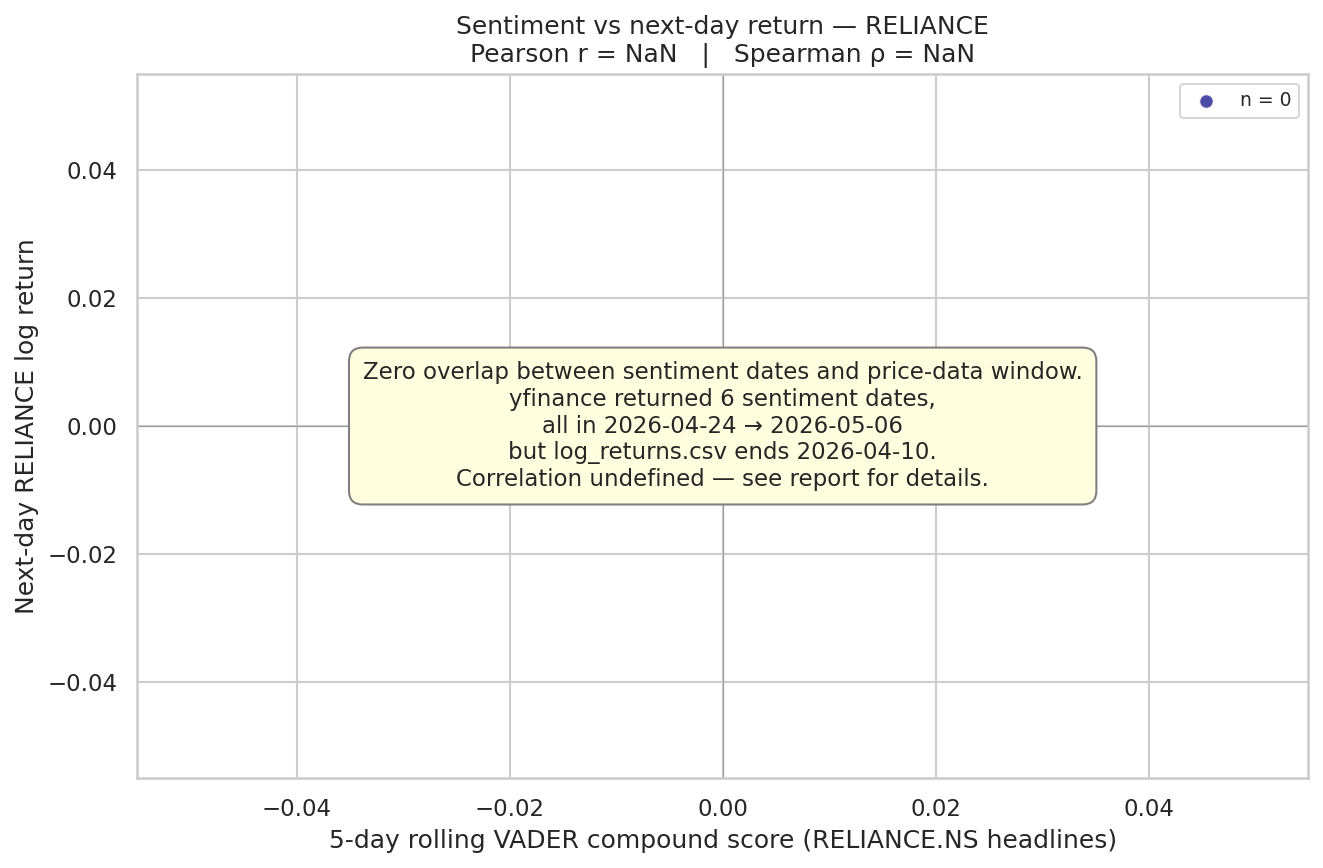

In [15]:
display(Image(filename=str(FIGURES / "sentiment_timeline.png")))
display(Image(filename=str(FIGURES / "sentiment_correlation.png")))


In [16]:
corr = pd.read_csv(METRICS / "sentiment_correlation.csv")
corr.T


,0
n,0
pearson_r,NaN
pearson_p,NaN
spearman_r,NaN
spearman_p,NaN
date_range_start,NaN
date_range_end,NaN
rolling_window,5


**Honest outcome on this run: zero overlap.** yfinance returned **10 headlines spanning 2026-04-24 → 2026-05-06** — every sentiment date sits *after* the directive's locked end-of-data (2026-04-10). `align_to_next_day_returns` finds **0 next-day pairs**, and Pearson and Spearman are formally undefined (`n = 0`, both r/p NaN). The scatter figure shows an explanatory banner instead of an empty axis.

**The sentiment-augmented LSTM** sits behind a gate (`n_aligned ≥ 100` *and* `overlap_with_train+val ≥ 60`) — training a 30k-parameter network on zero rows would be meaningless. Closed cleanly without doing it.

### 7.3 What VADER does and where it falls down

VADER fires sensibly on the extremes:

- Most-negative headline: compound = **−0.542** — bribery / detention story
- Most-positive headline: compound = **+0.818** — "Strong Digital Growth"

But the middle band is noisy: a headline like "snap losing streak" (neutral-to-positive on a recovery rally) reads negative because VADER's lexicon-and-rules engine sees "losing" without understanding the financial-news context. **This is the lexicon-vs-domain limitation** that motivates the obvious upgrade — replacing VADER with **FinBERT** (a BERT-base-cased model fine-tuned on financial communications), which would actually understand that *"losing streak"* in the context of a market recovery is a positive signal. Out of scope for this submission, flagged for §9.


## 8. Paper Trading — does the model make a better trader?

Sprint 09 takes each model's one-step-ahead RELIANCE prediction and trades it through a simple BUY/HOLD/SELL rule at the directive's ±0.5% log-return threshold, executing at next-day Open. Long-only, fractional shares, no transaction costs. ₹1,00,000 starting capital, 562-day test window. Buy-and-hold is the benchmark.


In [17]:
summary = pd.read_csv(METRICS / "paper_trading_summary.csv")
summary


,model,total_return_pct,annualised_return_pct,sharpe_ratio,max_drawdown_pct,n_trades,completed_round_trips,win_rate_pct,final_equity
0,ARIMA,0,0,NaN,0,0,0,NaN,100000
1,MLP,-8.4717,-3.8916,-0.3511,-29.4338,1,0,NaN,91528.3
2,LSTM,0,0,NaN,0,0,0,NaN,100000
3,BuyAndHold,3.6213,1.6079,-0.0892,-29.4338,1,0,NaN,103621


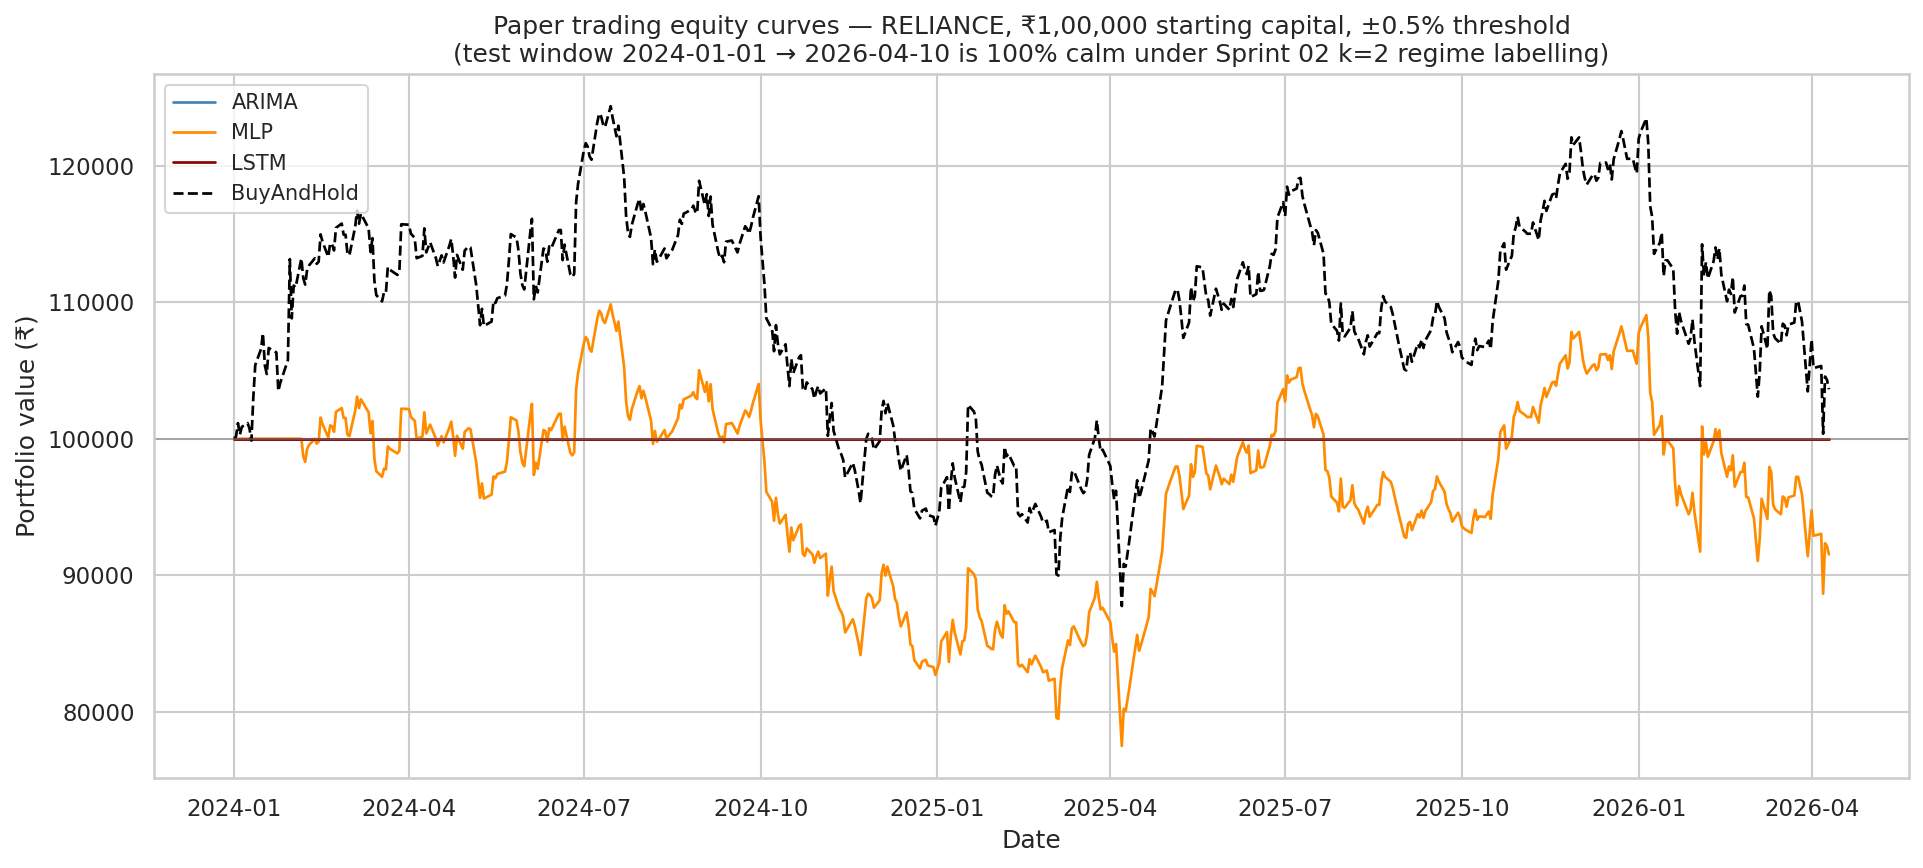

In [18]:
display(Image(filename=str(FIGURES / "equity_curves.png")))


**Headline: buy-and-hold wins.** BuyAndHold ends at +3.62%; ARIMA and LSTM never trade and finish flat at 0.00%; MLP fires once on 2024-02-05, holds into the trough, and ends at **−8.47%**.

### 8.1 Why ARIMA and LSTM never trade

The ±0.5% log-return threshold asks the model for a confident directional call. What the models actually produce on the test window:

| model | predicted log-return std | range | crossings of ±0.005 |
|---|---|---|---|
| ARIMA(0,0,0) | 0 | constant +0.0009 | 0 |
| LSTM | 5e-5 | [+0.00050, +0.00086] | 0 |
| MLP | 0.00127 | [-0.00403, +0.00619] | 6 (all BUY) |
| (realised) | 0.01373 | [-0.078, +0.078] | 200+ |

**Realised σ is an order of magnitude larger than every model's predicted σ.** ARIMA is literally a constant; the LSTM has collapsed to a near-flat ribbon (this is the LSTM's prediction doing exactly what early-stopping told us: regress to the noise floor and stop trying to hallucinate a signal). MLP has the widest band, just enough to clear the threshold 6 times — the first BUY consumes all cash so the next 5 are no-ops; the position is held into the drawdown that produces the −8.47%.

### 8.2 What this is really telling me

This is the **same noise-floor story** that §4–§6 told in RMSE/DA terms, now in P&L. The threshold filter is correctly rejecting un-actionable predictions on ARIMA and LSTM — a model firing hundreds of trades on near-zero edges would be **worse**, not better. The MLP gets the worst of both worlds: just enough spurious confidence to fire once at the wrong moment.

**Why this matters for the AI/ML reading.** A naive interpretation of the §6 master table would be "all models tie, so pick whichever's easiest to deploy". The paper trader exposes a more honest reading: the differences between models *do* show up in downstream behaviour, just not in the direction we'd hope. The MLP's wider prediction band — the same property that makes its RMSE numerically worst on the test window — is what causes its P&L disaster. **Lower training RMSE doesn't equal better trader.**


## 9. Conclusion

### What worked

- The full ML pipeline ran cleanly. Sliding-window framing, train-fit scaling, walk-forward test predictions, byte-deterministic PyTorch reruns. The mechanics are right.
- K-means picked out COVID as the only turbulent regime — predictable consequence of dynamic-range plus k=2, but a clean demonstration of unsupervised clustering on real data.
- Both neural networks early-stopped within 14 epochs on RELIANCE. Best-effort regularisation, no hand-tuning of dropout / weight decay needed. Early stopping is honestly an underrated baseline for noisy regression problems.
- The Diebold-Mariano test gave the right epistemic answer: the LSTM's small RMSE edge is **not** a real forecast-accuracy difference vs ARIMA. Better to know.
- The multivariate experiment produced a clean, interpretable negative result (Δ DA = +0.002). Adding parallel features whose correlation with the target is contemporaneous-not-leading doesn't help next-day prediction.

### What didn't

- **Neither neural net beat ARIMA.** The MLP, the LSTM, and the multivariate LSTM all tied a constant + drift on RMSE and DA. Most of the network's flexibility went unused — the data simply doesn't carry enough signal at the daily horizon for the extra capacity to matter.
- **Paper trading: buy-and-hold beat every model.** Predicted-σ vs realised-σ is off by an order of magnitude, so the threshold filter rejects ARIMA and LSTM trades and only lets the MLP fire (once, at the wrong moment).
- **K-means found one regime — COVID — and called everything else calm.** The directive's regime-split benchmark is consequently degenerate on the test window. Reported honestly rather than re-labelled to fit the spec.
- **Sentiment had zero overlap.** yfinance's news endpoint returned headlines from after the locked end-of-data, so Pearson/Spearman were formally undefined and the augmented-LSTM gate stayed closed.

### Limitations

- **Daily horizon.** Most exploitable structure in equity returns is intraday. At the daily horizon the signal-to-noise ratio is punishingly low, and any model that doesn't beat ARIMA(0,0,0) is telling us the data, not the model.
- **Single-asset paper trading.** Only RELIANCE traded. No portfolio construction across the seven tickers; no risk budget; no transaction costs or slippage. Adding any of these would make the picture *worse*, not better.
- **No hyperparameter search.** Used Bishop-Ch-5-defaults: Adam lr=1e-3, MSE, hidden sizes that look reasonable for the input dimension. A real architecture search (random search over depth / width / lr / dropout / lookback) might recover a few hundred bps of DA — but the noise-floor evidence suggests the ceiling is low.
- **Look-ahead caveats.** Time-based train/val/test split, scaler fit on train only, walk-forward forecasts. The k-means regime detector is fit on the full series (used as a labelling tool, not a predictive feature) — a stricter setup would refit expanding-window. Flagged.

### What I'd do differently with more time

- **Attention / Transformer baseline.** A small Transformer encoder on the 20-day window would be the obvious next architecture — it handles parallel features cleanly via cross-attention and might extract something from the multivariate setup that the LSTM couldn't.
- **Feature engineering** before more architectural depth. Realised volatility, trading volume, day-of-week, expiration-week dummies, macro indicators (USDINR, US 10y). The §5 multivariate experiment showed that *raw* contemporaneous-correlated features don't help; engineered leading features might.
- **FinBERT** instead of VADER for sentiment. Would actually handle the lexicon-vs-domain mismatch the §7 dive surfaced. Probably moot until yfinance returns a longer date range than 10 trailing headlines, but the upgrade is on the shelf.
- **Re-label regimes** with rolling-vol percentile bands (or a Markov-switching model) so the test window has *some* turbulent days. Would make §6's regime split non-degenerate and let us actually answer the directive's regime-split question.
- **Probabilistic forecasts.** Right now the models give a point prediction and §8 trades it through a deterministic threshold. A model that outputs $(\hat{\mu}, \hat{\sigma})$ — e.g. training with NLL under a Gaussian head — would let the trader size positions by predicted Sharpe rather than crossing a fixed threshold. Almost certainly the right next iteration.

### Closing

The headline finding for this course's submission is that the neural networks **did not beat the classical baseline**. ARIMA (0, 0, 0) — literally a constant — ties an MLP and an LSTM (and their multivariate variant) on RMSE and DA, with a Diebold-Mariano test confirming there's no real difference. In paper trading the constant-prediction models don't trade at all and the MLP loses 8.5%; buy-and-hold wins.

**This is a result worth writing down.** Not because it's unflattering to the AI/ML toolkit — it isn't, the toolkit worked exactly the way the textbook says it should — but because **the honest answer when the data doesn't carry enough signal is to say so, instead of finding a hyperparameter setting that manufactures one**. The early-stopping curves, the DM test, the prediction-σ-vs-threshold mismatch in paper trading — all of them are pointing at the same underlying fact: **daily Indian-equity log returns are close to white noise at this horizon**. More sophisticated models, applied honestly, give the same answer.

Source code: `scripts/01_eda.py` through `scripts/10_sentiment.py`. Sprint reports: `results/reports/01_eda.md` through `10_sentiment.md`. Time-series view of the same project: `rtsm/notebook.ipynb`.
